# Exercises

### Exercise 1
---
Use the sklearn `make_blobs()` function, in the same way that we used in the lesson, to generate a *non linearly separable* dataset with 2 features.  
Fit a linear SVM to the dataset many times, varying the slack hyperparameter $C$, and calculate the model performance in classifying the data.  
What is, approximately, a the best value of the $C$ hyperparameter for this dataset?

In [1]:
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt
from sklearn import svm
import numpy as np
import pickle
import seaborn as sns
import sys
import os
sys.path.append(os.path.abspath("code"))
from utils import download_data
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(context='notebook',style='white',font_scale=1.5,
              rc = {'axes.spines.top':False,'axes.spines.right':False})


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.5 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "c:\Users\EmielNagel\anaconda3\Lib\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "c:\Users\EmielNagel\anaconda3\Lib\site-packages\traitlets\config\application.py", line 1077, in launch_instance
    app.start()
  File "c:\Users\EmielNagel\anaconda3\Lib\site-packages\ipykernel\kernelapp.py", line 739, in start
    self.io_loop.start()
  File "c:\Users\EmielNagel\ana

ImportError: 
A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.5 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.




A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.5 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "c:\Users\EmielNagel\anaconda3\Lib\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "c:\Users\EmielNagel\anaconda3\Lib\site-packages\traitlets\config\application.py", line 1077, in launch_instance
    app.start()
  File "c:\Users\EmielNagel\anaconda3\Lib\site-packages\ipykernel\kernelapp.py", line 739, in start
    self.io_loop.start()
  File "c:\Users\EmielNagel\ana

ImportError: 
A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.5 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.



In [2]:
#donwload lesson data
download_data('https://surfdrive.surf.nl/files/index.php/s/NrNbvEOH7SImYLn')

In [3]:
X_sep,y_sep = make_blobs(n_samples=100,n_features =2,centers=[[-1,0],[1,0]],cluster_std=.3,)
X_nsep,y_nsep = make_blobs(n_samples=100,n_features =2,centers=[[-1,0],[1,0]],cluster_std=.8)

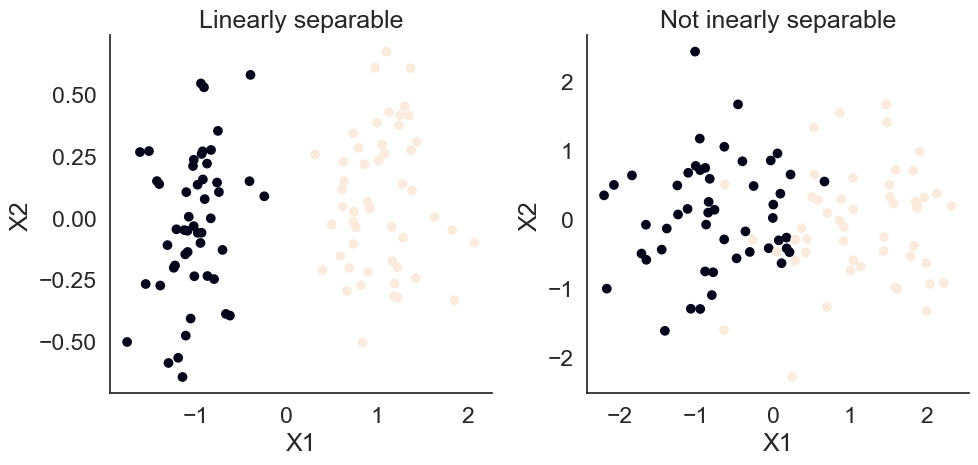

In [4]:
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.title('Linearly separable')
plt.xlabel('X1')
plt.ylabel('X2')
plt.scatter(X_sep[:,0],X_sep[:,1],c=y_sep)
plt.subplot(1,2,2)
plt.title('Not inearly separable')
plt.xlabel('X1')
plt.ylabel('X2')
plt.scatter(X_nsep[:,0],X_nsep[:,1],c=y_nsep)

plt.tight_layout()

C =   0.1  →  accuracy = 0.900
C =   0.3  →  accuracy = 0.900
C =   0.4  →  accuracy = 0.900
C =   0.5  →  accuracy = 0.910
C =   0.7  →  accuracy = 0.910
C =   0.8  →  accuracy = 0.910
C =   1.0  →  accuracy = 0.910


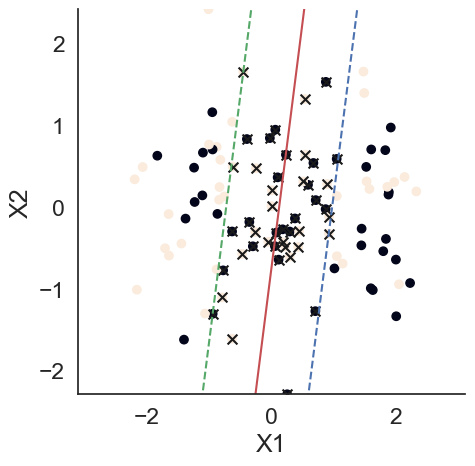

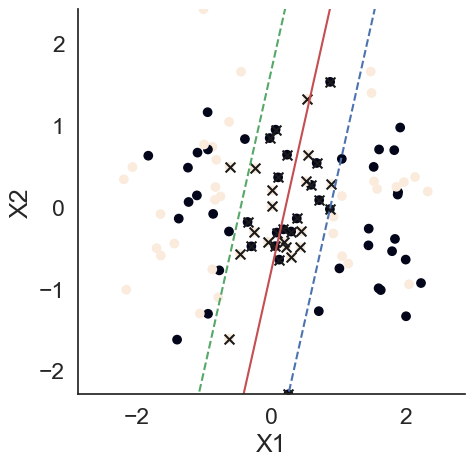

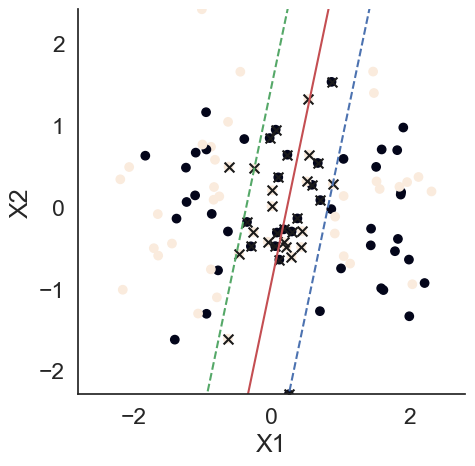

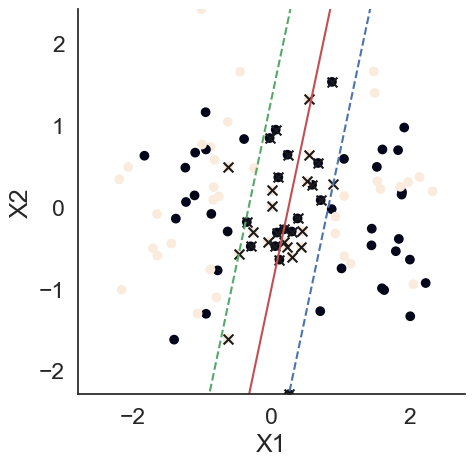

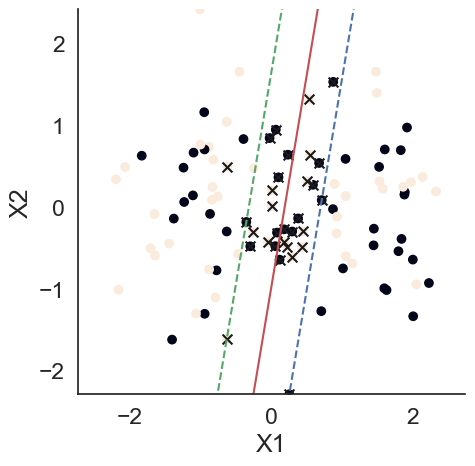

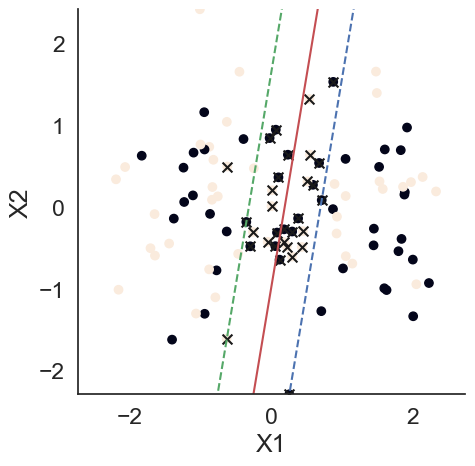

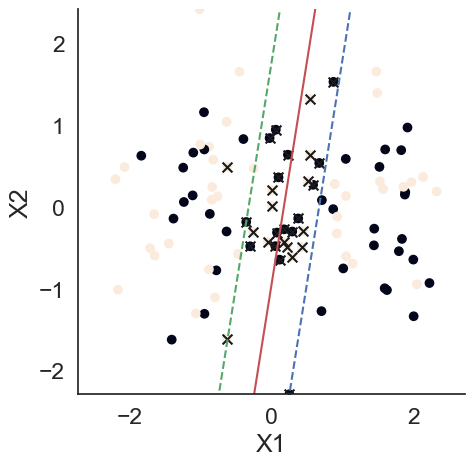

In [13]:
from sklearn.metrics import accuracy_score

for C in [0.1, 0.3, 0.4, 0.5, 0.7, 0.8, 1.0]:
    plt.figure(figsize=(5,5))
    X,y = X_nsep,y_nsep
    svc_model = svm.SVC(kernel='linear',C=C);
    svc_model.fit(X, y)


    plt.scatter(X[:,0],X[:,1],c=y_sep)
    # Constructing a hyperplane using a formula.
    w = svc_model.coef_[0]           # w consists of 2 elements
    b = svc_model.intercept_[0]      # b consists of 1 element
    x_points = np.linspace(-2,2)    # generating x-points from -1 to 1
    y_points = -(w[0] / w[1]) * x_points - b / w[1]  # getting corresponding y-points
    # Plotting a red hyperplane
    plt.plot(x_points, y_points, c='r');
    # Encircle support vectors
    plt.scatter(svc_model.support_vectors_[:, 0],
                svc_model.support_vectors_[:, 1], 
                s=50, 
                c='k',
                marker='x');
    # Step 2 (unit-vector):
    w_hat = svc_model.coef_[0] / (np.sqrt(np.sum(svc_model.coef_[0] ** 2)))
    # Step 3 (margin):
    margin = 1 / np.sqrt(np.sum(svc_model.coef_[0] ** 2))
    # Step 4 (calculate points of the margin lines):
    decision_boundary_points = np.array(list(zip(x_points, y_points)))
    points_of_line_above = decision_boundary_points + w_hat * margin
    points_of_line_below = decision_boundary_points - w_hat * margin
    # Plot margin lines
    # Blue margin line above
    plt.plot(points_of_line_above[:, 0], 
            points_of_line_above[:, 1], 
            'b--')
    # Green margin line below
    plt.plot(points_of_line_below[:, 0], 
            points_of_line_below[:, 1], 
            'g--')

    plt.ylim([min(X[:,1]),max(X[:,1])])

    plt.xlabel('X1')
    plt.ylabel('X2')

    y_pred = svc_model.predict(X)
    acc = accuracy_score(y, y_pred)
    print(f"C = {C:5.1f}  →  accuracy = {acc:.3f}")


The best value for C is approximately 0.5

### Exercise 2
---
Repeat exercise 1, but using a non-linear SVM model (the sklearn class `SVC` uses [Radial Basis Functions](https://en.wikipedia.org/wiki/Radial_basis_function) as a default, check its documentation [here](https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html#sklearn.svm.SVC)). 
To have a fairer assessment of the performance, train the model on a fraction (e.g. 80%) of the data, and test it on the other 20%.
Compare the performance of a linear SVC and a RBF SVC for dataset that are increaslingly non-linearly-separable.



Dataset: linearly separable

SVM with linear kernel

SVM with rbf kernel

Dataset: nonlinearly separable

SVM with linear kernel

SVM with rbf kernel


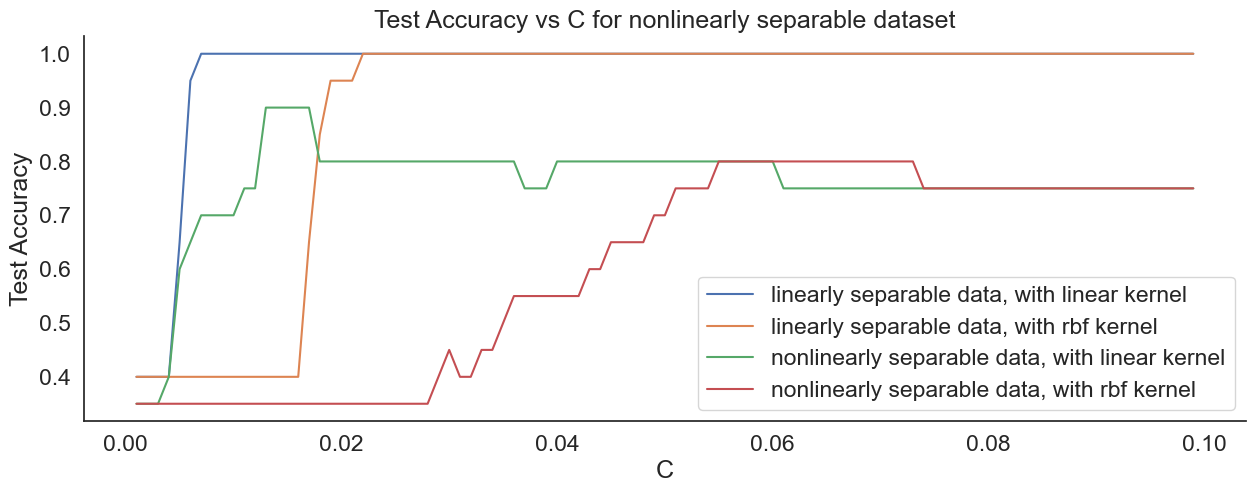

In [32]:
from sklearn.model_selection import train_test_split

plt.figure(figsize=(15, 5))

for label, X, y in [("linearly separable", X_sep, y_sep), ("nonlinearly separable", X_nsep, y_nsep)]:
    print(f"\nDataset: {label}")
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        train_size=0.8,
        shuffle=True,
        random_state=42
    )

    for kernel_type in ['linear', 'rbf']:
        print(f"\nSVM with {kernel_type} kernel")
        Cs, accs = [], []
        for C in np.arange(0.001, 0.1, 0.001):
            Cs.append(C)
            avg_acc = []
            for i in range(10):
                svc = svm.SVC(kernel=kernel_type, C=C, random_state=42)
                svc.fit(X_train, y_train)
                y_pred = svc.predict(X_test)
                acc = accuracy_score(y_test, y_pred)
                avg_acc.append(acc)
            accs.append(np.mean(avg_acc))

        plt.plot(Cs, accs, label=f"{label} data, with {kernel_type} kernel")

plt.xlabel('C')
plt.ylabel('Test Accuracy')
plt.title(f"Test Accuracy vs C for {label} dataset")
plt.legend()
plt.show()

As we can see, the linearly separable data is much easier to decode than nonlinearly separable data.
And in both cases, the linear kernel shows much higher performance than the rbf kernel for lower values of C.
But both kernel types are capable of reaching similar states of accuracy.

### Exercise 3
---
Use the code below to simulate new data.
Generate data and then decode the stimulus identity, see how the decoding performance change when you change the following:

- The amplitude of the noise in the firing rate
- The amplitude of the stimulus modulation of the firing rate
- The number of neurons

Plot and comment.

## Useful code
---


In [39]:
from sklearn.model_selection import StratifiedKFold
from sklearn import svm
from sklearn.preprocessing import StandardScaler

def decode(spike_times, stim_onsets, stim_type, stim_duration):
    onset = -1 # in seconds before stimulus onset
    offset = 1 # in second after stimulus offset

    binwidth = 0.1 # in seconds (100 ms)
    bins = np.arange(onset,stim_duration+offset+binwidth,binwidth)

    n_cells = len(spike_times)
    n_trials= len(stim_type)

    X = np.zeros((n_cells,n_trials,len(bins)-1));
    for cell in range(n_cells):    
        for trial in range(n_trials):

            # selects spikes that are in trial
            sp_idx = np.logical_and(spike_times[cell]>stim_onsets[trial]-onset,
                    spike_times[cell]<stim_onsets[trial]+stim_duration+offset)
            
            # centers spike times around stimulus onset
            sp_cntr = spike_times[cell][sp_idx]-stim_onsets[trial]
            #bins spikes
            spike_count,_ = np.histogram(sp_cntr,bins)
            #spike_count = zscore(spike_count)
            X[cell,trial,:] = spike_count
    
    n_splits = 5

    avg_performance = []
    std_performance = []

    for time_bin in range(X.shape[-1]):
            # setting 2-fold cross validation
            kf = StratifiedKFold(n_splits=n_splits,shuffle=True)
            fold_performance = []

            for train_index, test_index in kf.split(X[:,:,time_bin].T,stim_type):
                    

                    X_train, X_test = X[:,train_index,time_bin].T, X[:,test_index,time_bin].T
                    y_train, y_test = stim_type[train_index], stim_type[test_index]

                    clf = svm.LinearSVC(max_iter=1000)
                    clf.fit(X_train, y_train)
                    fold_performance.append(clf.score(X_test,y_test))

            avg_performance.append(np.mean(fold_performance))
            std_performance.append(np.std(fold_performance))

    avg_performance = np.asarray(avg_performance)
    std_performance = np.asarray(std_performance)

    return avg_performance, std_performance

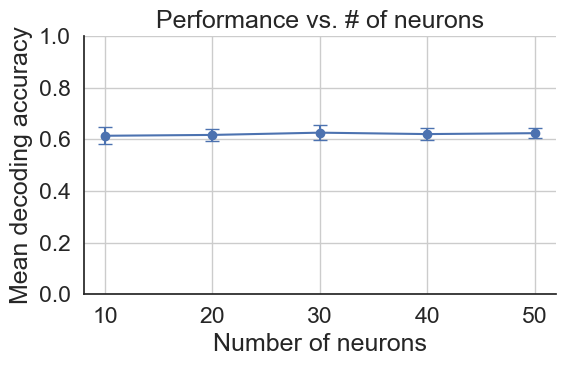

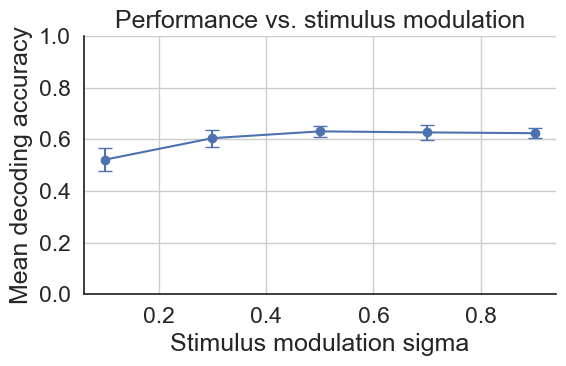

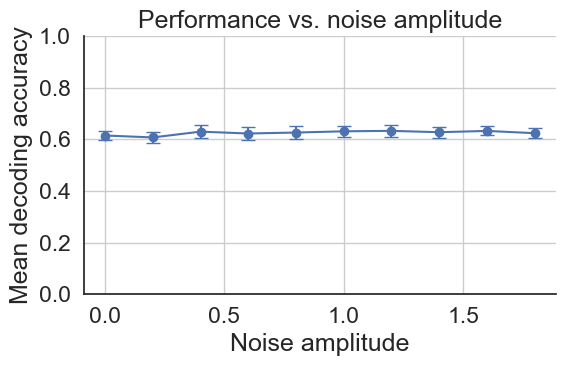

In [47]:
import numpy as np
import matplotlib.pyplot as plt
import pickle

n_cell_data_avg = {}
n_cell_data_std = {}
sigma_stim_data_avg = {}
sigma_stim_data_std = {}
noise_rate_data_avg = {}
noise_rate_data_std = {}

for noise_rate in np.arange(0.0, 2.0, 0.2):
    for sigma_stim in np.arange(0.1, 1.0, 0.2):
        for n_cells in [10, 20, 30, 40, 50]:
            n_stim_type = 2; # number of different stimuli
            average_firing_rate = 5; # average firing rate across the population

            # generate baseline rates from exponential distirbution
            cell_rate_baseline = np.random.exponential(average_firing_rate,size=n_cells)

            # create stimulus average responses, perturbing the population firng rate profile
            # we use a multiplicative modulation in opposite directions for the two stimuli
            modulation = sigma_stim*np.random.normal(0,1,size=n_cells)
            cell_rate_stim = {1: cell_rate_baseline * (1+modulation),2:cell_rate_baseline * (1-modulation)}
            # sets negative firng rate to 0
            cell_rate_stim[1][cell_rate_stim[1]<0]=0
            cell_rate_stim[2][cell_rate_stim[2]<0]=0


            # simulate spiking activity

            s_rate = 10000 # the sampling rate of our emulated recording system
            n_stim = 100 # number of stimuli

            stim_dur = 2 #stimulus duration (in seconds)
            is_interval = 3 # interval between stimuli  (in seconds)

            stim_onsets = np.arange(0,n_stim*(stim_dur+is_interval),(stim_dur+is_interval)) # onset time of each stimulus (in seconds)
            stim_type = np.asarray([1 for i in range(int(n_stim/2))]+[2 for i in range(int(n_stim/2))]) # identity of each stimulus
            np.random.shuffle(stim_type)

            time = np.arange(0,(n_stim+1)*(stim_dur+is_interval),1.0/s_rate) # vector of the sampled times.

            spike_times = []
            for cell in range(n_cells):
                spikes = np.random.poisson(cell_rate_baseline[cell]/s_rate,size=time.shape)
                for i,stimulus in enumerate(stim_type):
                    stim_idxs = np.arange(stim_onsets[i]*s_rate,(stim_onsets[i]+stim_dur)*s_rate)
                    spikes[stim_idxs] = np.random.poisson(cell_rate_stim[stimulus][cell]/s_rate,size=stim_idxs.shape)

                spike_times.append(time[spikes>0])

            avg_performance, std_performance = decode(spike_times, stim_onsets, stim_type, stim_dur)

            n_cell_data_avg[n_cells] = avg_performance
            n_cell_data_std[n_cells] = std_performance
            sigma_stim_data_avg[sigma_stim] = avg_performance
            sigma_stim_data_std[sigma_stim] = std_performance
            noise_rate_data_avg[noise_rate] = avg_performance
            noise_rate_data_std[noise_rate] = std_performance

cells   = sorted(n_cell_data_avg.keys())
cells_mean = [np.mean(n_cell_data_avg[n]) for n in cells]
cells_err  = [np.mean(n_cell_data_std[n]) for n in cells]

sigmas  = sorted(sigma_stim_data_avg.keys())
sigma_mean = [np.mean(sigma_stim_data_avg[s]) for s in sigmas]
sigma_err  = [np.mean(sigma_stim_data_std[s]) for s in sigmas]

noises  = sorted(noise_rate_data_avg.keys())
noise_mean = [np.mean(noise_rate_data_avg[n]) for n in noises]
noise_err  = [np.mean(noise_rate_data_std[n]) for n in noises]

plt.figure(figsize=(6,4))
plt.errorbar(cells, cells_mean, yerr=cells_err, fmt='-o', capsize=5)
plt.xlabel('Number of neurons')
plt.ylabel('Mean decoding accuracy')
plt.title('Performance vs. # of neurons')
plt.ylim(0,1)
plt.grid(True)
plt.tight_layout()

plt.figure(figsize=(6,4))
plt.errorbar(sigmas, sigma_mean, yerr=sigma_err, fmt='-o', capsize=5)
plt.xlabel('Stimulus modulation sigma')
plt.ylabel('Mean decoding accuracy')
plt.title('Performance vs. stimulus modulation')
plt.ylim(0,1)
plt.grid(True)
plt.tight_layout()

plt.figure(figsize=(6,4))
plt.errorbar(noises, noise_mean, yerr=noise_err, fmt='-o', capsize=5)
plt.xlabel('Noise amplitude')
plt.ylabel('Mean decoding accuracy')
plt.title('Performance vs. noise amplitude')
plt.ylim(0,1)
plt.grid(True)
plt.tight_layout()

plt.show()


As can be seen in the plots, varying the number of neurons or the noise amplitude has very little effect on decoding performance.
On the other hand, the performance as function of stimulus modulation seems to decrease as the sigma goes down to 0. 
The effect is minimal, but could be significant when sigma=0.0, it's currently lower-bounded to 0.1.